# Bicing E-Bike Depletion Analysis — UB/UPC Nord Cluster

**Scope:** 2021–2024, bikes_20XX_with_weather.csv.gz  
**Cluster:** UB / UPC Nord (6 stations within 500m of campus centroids)  
**Goal:** Analyse temporal and weather-driven e-bike behaviour, build a 24h-ahead hourly NAB regressor, and derive a depletion classifier from its predictions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import os, warnings
warnings.filterwarnings('ignore')
from math import radians, cos, sin, asin, sqrt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ── Palette ────────────────────────────────────────────────────────────────
C_EBIKE  = '#5B4FBE'
C_MECH   = '#1D9E75'
C_DEPL   = '#E8593C'
C_PRED   = '#BA7517'
C_YEST   = '#8A8899'
C_ACTUAL = '#5B4FBE'
SUMMER   = [7, 8, 9]

CLUSTER_COLORS = {
    'UB / UPC Nord'  : '#5B4FBE',
    'UB / UPC Sud'   : '#E8593C',
    'UPF Ciutadella' : '#1D9E75',
}

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f8f8',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11,
})
print('Setup complete.')

Setup complete.


## 1 — Define clusters and load data

In [3]:
CLUSTERS = {
    'UB / UPC Nord'  : {'lat': 41.3888, 'lon': 2.1147},
    'UB / UPC Sud'   : {'lat': 41.3773, 'lon': 2.1492},
    'UPF Ciutadella' : {'lat': 41.3854, 'lon': 2.1938},
}
RADIUS_M = 500

def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2*asin(sqrt(a))*6371*1000

# Get station coordinates
coords_df = (
    pd.read_csv('bikes_2023_with_weather.csv.gz', compression='gzip',
                usecols=['station_id','latitude','longitude'])
    .drop_duplicates('station_id').dropna()
)

# Assign stations to clusters
rows = []
for _, st in coords_df.iterrows():
    best, dist = None, float('inf')
    for name, c in CLUSTERS.items():
        d = haversine(c['lon'], c['lat'], st['longitude'], st['latitude'])
        if d <= RADIUS_M and d < dist:
            best, dist = name, d
    if best:
        rows.append({'station_id': st['station_id'], 'cluster': best,
                     'latitude': st['latitude'], 'longitude': st['longitude']})

cluster_stations = pd.DataFrame(rows)
NORD_IDS = set(cluster_stations[cluster_stations['cluster']=='UB / UPC Nord']['station_id'])
ALL_CLUSTER_IDS = set(cluster_stations['station_id'])

print('Stations per cluster:')
for name, grp in cluster_stations.groupby('cluster'):
    print(f'  {name}: {len(grp)} stations  {sorted(grp["station_id"].astype(int).tolist())}')
print(f'\nNord station IDs: {sorted([int(x) for x in NORD_IDS])}')

Stations per cluster:
  UB / UPC Nord: 6 stations  [302, 422, 429, 430, 432, 433]
  UB / UPC Sud: 14 stations  [81, 82, 94, 95, 96, 97, 100, 186, 236, 262, 384, 420, 445, 495]
  UPF Ciutadella: 10 stations  [11, 12, 13, 46, 69, 116, 125, 396, 398, 408]

Nord station IDs: [302, 422, 429, 430, 432, 433]


In [4]:
# ── Load 2021-2024 for all cluster stations ────────────────────────────────
FILES = [
    'bikes_2021_with_weather.csv.gz',
    'bikes_2022_with_weather.csv.gz',
    'bikes_2023_with_weather.csv.gz',
    'bikes_2024_with_weather.csv.gz',
]
COLS = [
    'station_id','date','ebikes','mechanical_bikes',
    'bikes_available','docks_available',
    'temperature_2m','precipitation','windspeed_10m',
    'is_raining','is_windy','weather_severity',
]

frames = []
for path in FILES:
    if not os.path.exists(path):
        print(f'  ⚠  Not found: {path}')
        continue
    avail = pd.read_csv(path, compression='gzip', nrows=0).columns.tolist()
    load  = [c for c in COLS if c in avail]
    df_y  = pd.read_csv(path, compression='gzip', usecols=load)
    df_y  = df_y[df_y['station_id'].isin(ALL_CLUSTER_IDS)]
    frames.append(df_y)
    print(f'  ✓ {path}: {len(df_y):,} rows')

df = pd.concat(frames, ignore_index=True)
df['date']        = pd.to_datetime(df['date'])
df['hour']        = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month']       = df['date'].dt.month
df['year']        = df['date'].dt.year
df['is_weekend']  = df['day_of_week'].isin([5,6])
df['date_only']   = df['date'].dt.normalize()
df['capacity']    = (df['bikes_available'] + df['docks_available']).clip(lower=1)
df['ebike_NAB']   = df['ebikes'] / df['capacity']
df['mech_NAB']    = df['mechanical_bikes'] / df['capacity']
df = df.merge(cluster_stations[['station_id','cluster']], on='station_id', how='left')

print(f'\nLoaded: {len(df):,} rows | {df["date"].min().date()} → {df["date"].max().date()}')

  ✓ bikes_2021_with_weather.csv.gz: 259,968 rows
  ✓ bikes_2022_with_weather.csv.gz: 254,073 rows
  ✓ bikes_2023_with_weather.csv.gz: 235,441 rows
  ✓ bikes_2024_with_weather.csv.gz: 64,425 rows

Loaded: 813,907 rows | 2021-01-01 → 2024-03-31


## 2 — Why UB/UPC Nord? Cluster comparison

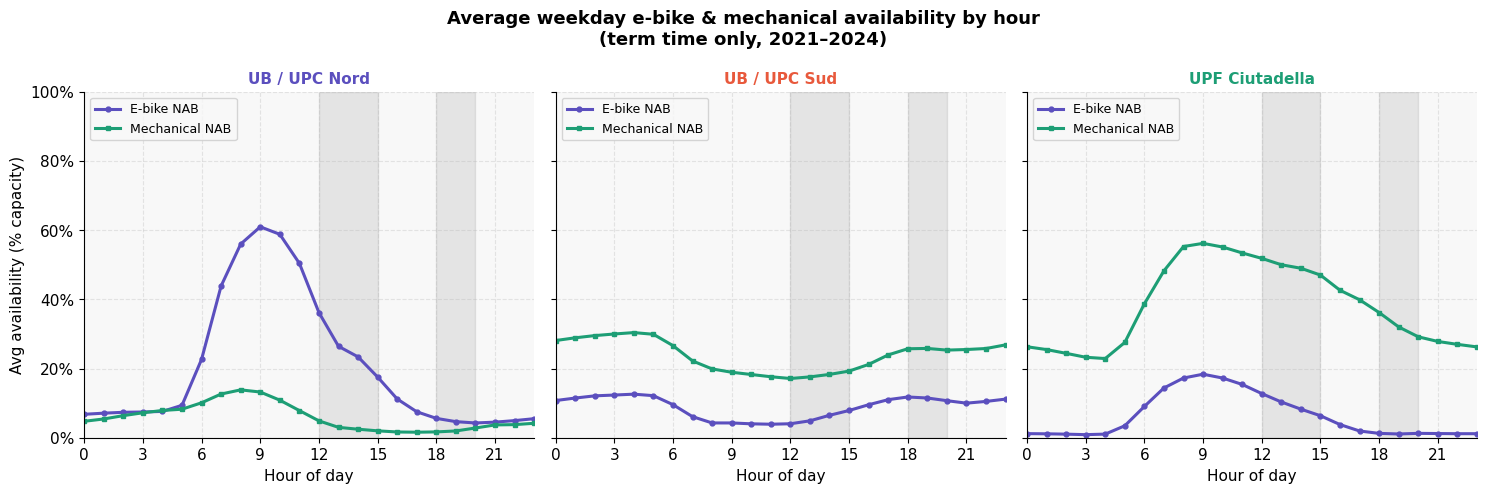

Saved: fig_cluster_comparison.png


In [5]:
# ── Hourly e-bike vs mechanical comparison across all 3 clusters ───────────
term_wd = df[~df['is_weekend'] & ~df['month'].isin(SUMMER)].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle(
    'Average weekday e-bike & mechanical availability by hour\n'
    '(term time only, 2021–2024)',
    fontsize=13, fontweight='bold'
)

for ax, (name, color) in zip(axes, CLUSTER_COLORS.items()):
    grp = term_wd[term_wd['cluster'] == name]
    hourly_e = grp.groupby('hour')['ebike_NAB'].mean() * 100
    hourly_m = grp.groupby('hour')['mech_NAB'].mean()  * 100

    ax.plot(hourly_e.index, hourly_e.values, color=C_EBIKE, lw=2.2,
            marker='o', ms=3.5, label='E-bike NAB')
    ax.plot(hourly_m.index, hourly_m.values, color=C_MECH,  lw=2.2,
            marker='s', ms=3.5, label='Mechanical NAB')

    ax.axvspan(12, 15, alpha=0.08, color='black')
    ax.axvspan(18, 20, alpha=0.08, color='black')
    ax.set_title(name, fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Hour of day')
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlim(0, 23)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')

axes[0].set_ylabel('Avg availability (% capacity)')
plt.tight_layout()
plt.savefig('fig_cluster_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_cluster_comparison.png')

In [6]:
# ── 6am stock table to quantify e-bike vs mechanical split ────────────────
morning = df[df['hour'] == 6].copy()
stock = morning.groupby('cluster').agg(
    avg_ebikes   =('ebikes',          'mean'),
    avg_mech     =('mechanical_bikes','mean'),
    avg_capacity =('capacity',        'mean'),
).round(2)
stock['ebike_share_pct'] = (stock['avg_ebikes'] / stock['avg_capacity'] * 100).round(1)
stock['mech_share_pct']  = (stock['avg_mech']   / stock['avg_capacity'] * 100).round(1)
print('6am stock by cluster:')
print(stock[['avg_ebikes','avg_mech','avg_capacity','ebike_share_pct','mech_share_pct']].to_string())

6am stock by cluster:
                avg_ebikes  avg_mech  avg_capacity  ebike_share_pct  mech_share_pct
cluster                                                                            
UB / UPC Nord         5.28      2.81         27.70             19.1            10.1
UB / UPC Sud          2.21      6.70         24.89              8.9            26.9
UPF Ciutadella        2.27     12.37         34.43              6.6            35.9


## 3 — UB/UPC Nord deep-dive

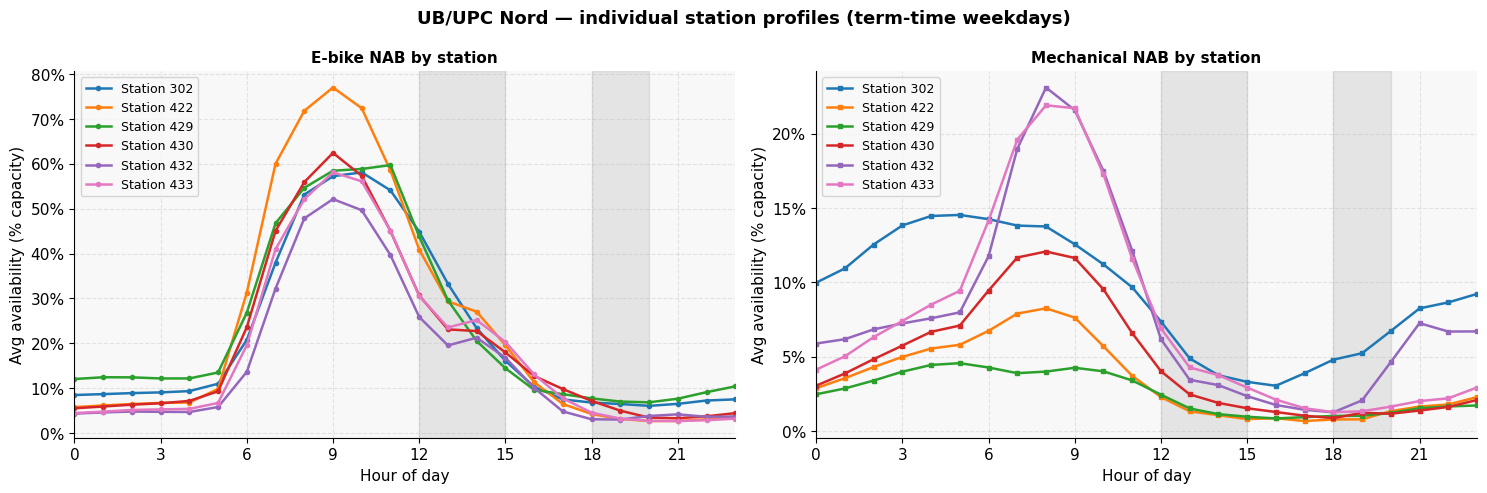

Saved: fig_nord_individual_stations.png


In [7]:
# ── Individual station profiles within Nord — outlier check ───────────────
nord = df[df['cluster'] == 'UB / UPC Nord'].copy()
nord_term_wd = nord[~nord['is_weekend'] & ~nord['month'].isin(SUMMER)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('UB/UPC Nord — individual station profiles (term-time weekdays)',
             fontsize=13, fontweight='bold')

station_colors = plt.cm.tab10(np.linspace(0, 0.6, len(NORD_IDS)))

for (sid, c) in zip(sorted(NORD_IDS), station_colors):
    s = nord_term_wd[nord_term_wd['station_id'] == sid]
    h_e = s.groupby('hour')['ebike_NAB'].mean() * 100
    h_m = s.groupby('hour')['mech_NAB'].mean()  * 100
    label = f'Station {int(sid)}'
    ax1.plot(h_e.index, h_e.values, lw=1.8, color=c, label=label, marker='o', ms=3)
    ax2.plot(h_m.index, h_m.values, lw=1.8, color=c, label=label, marker='s', ms=3)

for ax, title in [(ax1,'E-bike NAB by station'), (ax2,'Mechanical NAB by station')]:
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Avg availability (% capacity)')
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlim(0, 23)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.axvspan(12, 15, alpha=0.08, color='black')
    ax.axvspan(18, 20, alpha=0.08, color='black')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('fig_nord_individual_stations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_nord_individual_stations.png')

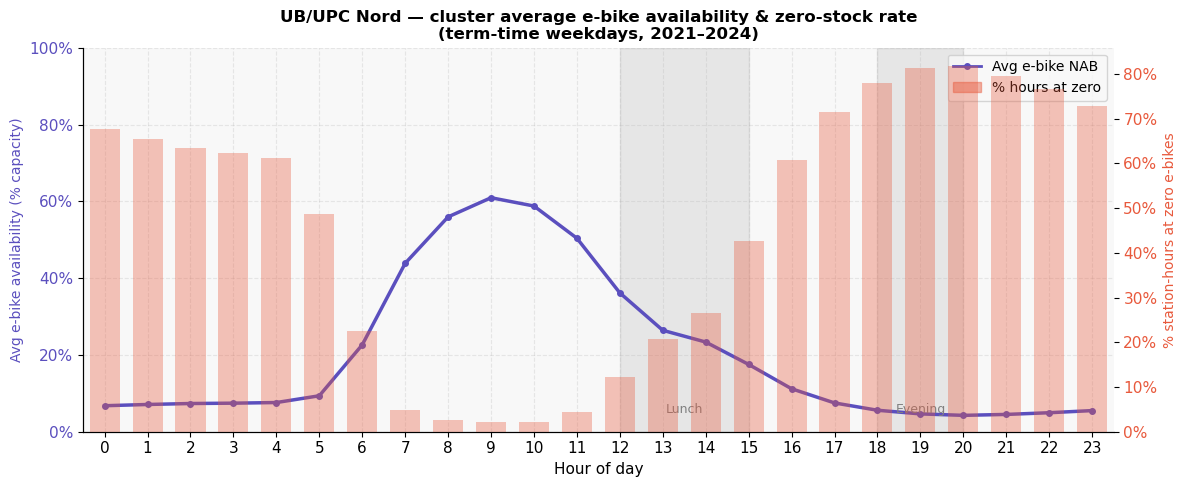

Saved: fig_nord_cluster_average.png


In [8]:
# ── Nord cluster average — e-bike availability & zero-stock rate ──────────
def consecutive_zeros_rate(series):
    """Fraction of hours in series where ebike_NAB < 0.05 for 1+ consecutive hours."""
    flags = (series < 0.05).astype(int)
    count = 0
    for v in flags:
        count = count + 1 if v else 0
        if count >= 1:
            return 1
    return 0

hourly_avg = nord_term_wd.groupby('hour')['ebike_NAB'].mean() * 100

# Zero-stock rate per hour (fraction of station-days at near-zero)
zero_by_hour = (
    nord_term_wd
    .assign(is_zero=(nord_term_wd['ebike_NAB'] < 0.05).astype(int))
    .groupby('hour')['is_zero']
    .mean() * 100
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax2.bar(zero_by_hour.index, zero_by_hour.values,
        color=C_DEPL, alpha=0.35, width=0.7, zorder=1)
ax2.set_ylabel('% station-hours at zero e-bikes', color=C_DEPL, fontsize=10)
ax2.tick_params(axis='y', labelcolor=C_DEPL)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))

ax1.plot(hourly_avg.index, hourly_avg.values, color=C_EBIKE, lw=2.5,
         marker='o', ms=4, zorder=3, label='Avg e-bike NAB')
ax1.set_ylabel('Avg e-bike availability (% capacity)', color=C_EBIKE, fontsize=10)
ax1.tick_params(axis='y', labelcolor=C_EBIKE)
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax1.set_xlabel('Hour of day', fontsize=11)
ax1.set_xticks(range(0, 24))
ax1.set_xlim(-0.5, 23.5)
ax1.axvspan(12, 15, alpha=0.07, color='black')
ax1.axvspan(18, 20, alpha=0.07, color='black')
ax1.text(13.5, 5, 'Lunch', ha='center', fontsize=9, color='gray')
ax1.text(19,   5, 'Evening', ha='center', fontsize=9, color='gray')
ax1.set_title('UB/UPC Nord — cluster average e-bike availability & zero-stock rate\n'
              '(term-time weekdays, 2021–2024)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.25, linestyle='--', zorder=0)

handles = [
    plt.Line2D([0],[0], color=C_EBIKE, lw=2, marker='o', ms=4, label='Avg e-bike NAB'),
    mpatches.Patch(color=C_DEPL, alpha=0.45, label='% hours at zero'),
]
ax1.legend(handles=handles, fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig('fig_nord_cluster_average.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_nord_cluster_average.png')

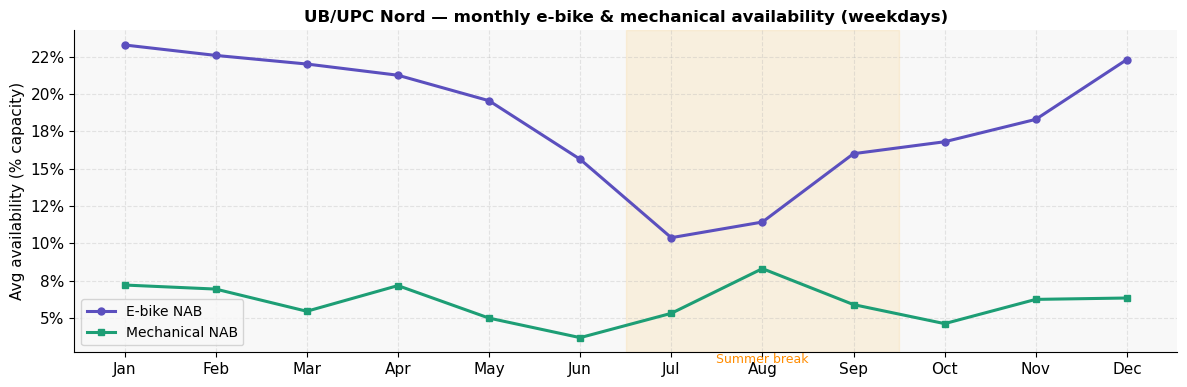

Saved: fig_nord_monthly.png


In [9]:
# ── Monthly pattern — academic year view ──────────────────────────────────
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

nord_wd = nord[~nord['is_weekend']].copy()
monthly = nord_wd.groupby('month').agg(
    ebike_NAB=('ebike_NAB','mean'),
    mech_NAB =('mech_NAB', 'mean'),
).reindex(range(1,13))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly.index, monthly['ebike_NAB']*100, color=C_EBIKE, lw=2.2,
        marker='o', ms=5, label='E-bike NAB')
ax.plot(monthly.index, monthly['mech_NAB']*100,  color=C_MECH,  lw=2.2,
        marker='s', ms=5, label='Mechanical NAB')
ax.axvspan(6.5, 9.5, alpha=0.10, color='orange')
ax.text(8, 2, 'Summer break', ha='center', fontsize=9, color='darkorange')
ax.set_xticks(range(1,13))
ax.set_xticklabels(MONTH_LABELS)
ax.set_ylabel('Avg availability (% capacity)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_title('UB/UPC Nord — monthly e-bike & mechanical availability (weekdays)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('fig_nord_monthly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_nord_monthly.png')

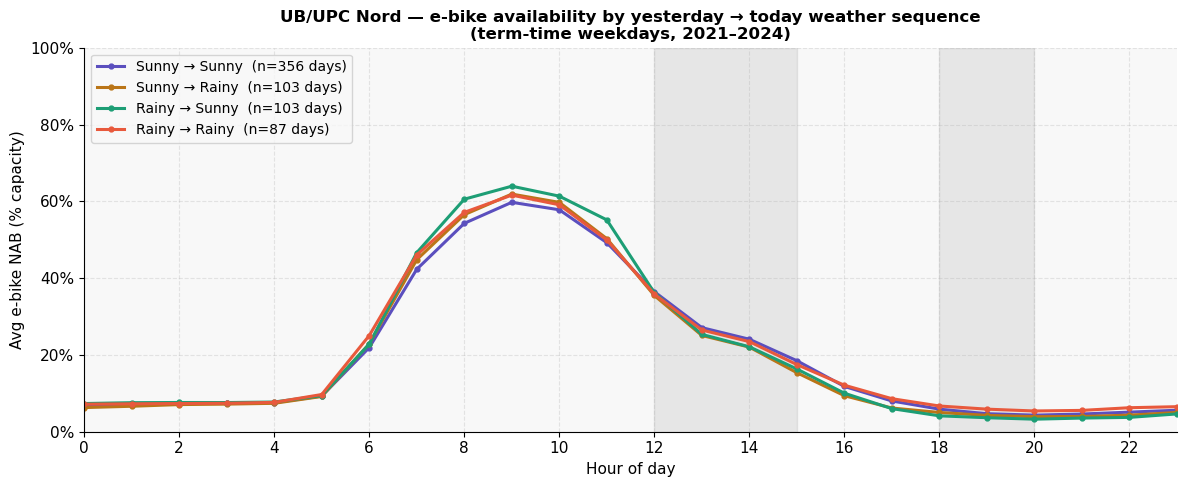

Saved: fig_nord_weather_sequences.png

Sample sizes per sequence:
sequence
Rainy → Rainy     87
Rainy → Sunny    103
Sunny → Rainy    103
Sunny → Sunny    356


In [10]:
# ── Weather sequence analysis ─────────────────────────────────────────────
# Rainy = is_raining == True on that day (any hour)
# We classify each day as rainy or sunny, then look at the NEXT day's profile
# conditioned on both today and yesterday's weather

# Daily rain flag per station-day
daily_rain = (
    nord_term_wd
    .groupby(['station_id','date_only'])['is_raining']
    .max()  # 1 if any hour was raining
    .reset_index()
    .rename(columns={'is_raining':'today_rain'})
)
daily_rain['date_only'] = pd.to_datetime(daily_rain['date_only'])

# Shift to get yesterday's rain flag
daily_rain = daily_rain.sort_values(['station_id','date_only'])
daily_rain['yesterday_rain'] = daily_rain.groupby('station_id')['today_rain'].shift(1)
daily_rain = daily_rain.dropna(subset=['yesterday_rain'])
daily_rain['sequence'] = daily_rain.apply(
    lambda r: ('Rainy' if r['yesterday_rain'] else 'Sunny') +
              ' → ' +
              ('Rainy' if r['today_rain'] else 'Sunny'), axis=1
)

# Merge sequence back onto hourly data
nord_seq = nord_term_wd.merge(
    daily_rain[['station_id','date_only','sequence']],
    on=['station_id','date_only'], how='left'
).dropna(subset=['sequence'])

SEQUENCES = ['Sunny → Sunny','Sunny → Rainy','Rainy → Sunny','Rainy → Rainy']
SEQ_COLORS = [C_EBIKE, C_PRED, C_MECH, C_DEPL]

fig, ax = plt.subplots(figsize=(12, 5))
for seq, color in zip(SEQUENCES, SEQ_COLORS):
    sub = nord_seq[nord_seq['sequence'] == seq]
    if len(sub) == 0:
        continue
    n_days = sub['date_only'].nunique()
    h = sub.groupby('hour')['ebike_NAB'].mean() * 100
    ax.plot(h.index, h.values, color=color, lw=2.2,
            label=f'{seq}  (n={n_days} days)', marker='o', ms=3.5)

ax.axvspan(12, 15, alpha=0.07, color='black')
ax.axvspan(18, 20, alpha=0.07, color='black')
ax.set_xlabel('Hour of day', fontsize=11)
ax.set_ylabel('Avg e-bike NAB (% capacity)', fontsize=11)
ax.set_xticks(range(0, 24, 2))
ax.set_xlim(0, 23)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_title('UB/UPC Nord — e-bike availability by yesterday → today weather sequence\n'
             '(term-time weekdays, 2021–2024)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('fig_nord_weather_sequences.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_nord_weather_sequences.png')

print('\nSample sizes per sequence:')
print(nord_seq.groupby('sequence')['date_only'].nunique().to_string())

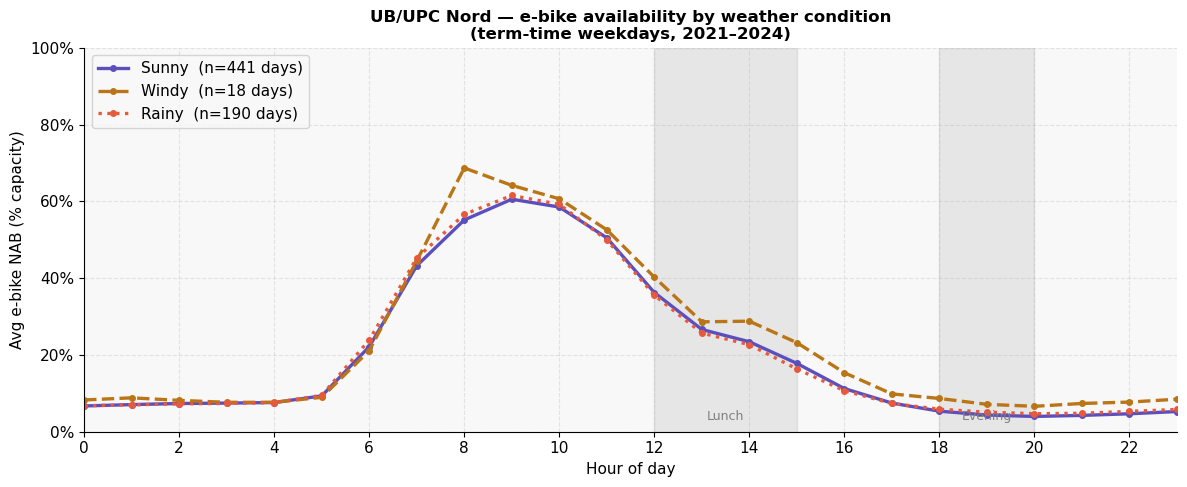

Saved: fig_nord_weather_conditions.png

Sample sizes:
condition
Sunny    2632
Rainy    1136
Windy     108


In [11]:
# ── Weather conditions: sunny vs rainy vs windy ───────────────────────────
# Three simple conditions using the day's actual weather
# Mutually exclusive priority: rainy > windy > sunny

nord_term_wd['date_only'] = pd.to_datetime(nord_term_wd['date_only'])

# Daily weather flags (any hour triggers the flag)
daily_weather = (
    nord_term_wd
    .groupby(['station_id', 'date_only'])
    .agg(
        any_rain=('is_raining', 'max'),
        any_wind=('is_windy',   'max'),
    )
    .reset_index()
)

# Assign condition — rainy takes priority over windy
daily_weather['condition'] = 'Sunny'
daily_weather.loc[daily_weather['any_wind'] == 1, 'condition'] = 'Windy'
daily_weather.loc[daily_weather['any_rain'] == 1, 'condition'] = 'Rainy'

# Merge back onto hourly data
nord_weather = nord_term_wd.merge(
    daily_weather[['station_id', 'date_only', 'condition']],
    on=['station_id', 'date_only'], how='left'
)

CONDITIONS  = ['Sunny', 'Windy', 'Rainy']
COND_COLORS = [C_EBIKE, C_PRED, C_DEPL]
COND_STYLES = ['-',     '--',    ':']

fig, ax = plt.subplots(figsize=(12, 5))

for cond, color, style in zip(CONDITIONS, COND_COLORS, COND_STYLES):
    sub    = nord_weather[nord_weather['condition'] == cond]
    n_days = sub['date_only'].nunique()
    h      = sub.groupby('hour')['ebike_NAB'].mean() * 100
    ax.plot(h.index, h.values,
            color=color, lw=2.4, linestyle=style,
            marker='o', ms=4,
            label=f'{cond}  (n={n_days} days)')

ax.axvspan(12, 15, alpha=0.07, color='black')
ax.axvspan(18, 20, alpha=0.07, color='black')
ax.text(13.5, 3, 'Lunch', ha='center', fontsize=9, color='gray')
ax.text(19,   3, 'Evening', ha='center', fontsize=9, color='gray')

ax.set_xlabel('Hour of day', fontsize=11)
ax.set_ylabel('Avg e-bike NAB (% capacity)', fontsize=11)
ax.set_xticks(range(0, 24, 2))
ax.set_xlim(0, 23)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_title(
    'UB/UPC Nord — e-bike availability by weather condition\n'
    '(term-time weekdays, 2021–2024)',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('fig_nord_weather_conditions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_nord_weather_conditions.png')

print('\nSample sizes:')
print(daily_weather['condition'].value_counts().to_string())

Observation: Windy Days have slightly higher availibility (the data is also limited though compared to Sunny and Windy)

## 4 — 24h-ahead hourly NAB regression model

**One row = one station × one hour.**  
Features are all knowable at midnight the day before — no same-day rolling lags.  
**Train:** 2021–2023 (term-time weekdays)  
**Test:** 2024 (term-time weekdays)

In [12]:
def is_academic(month, day):
    if month in [7, 8, 9]:                                       return 0
    if (month == 12 and day >= 20) or (month == 1 and day <= 7): return 0
    if month == 4 and day <= 7:                                  return 0
    return 1

# ── Build feature table ─removing summer, weekends, overnight hours───────────────────────────────────────────────────
nord_model = nord[
    ~nord['is_weekend'] &
    ~nord['month'].isin(SUMMER) &
    nord['hour'].between(6, 22)          # drop overnight hours
].copy().sort_values(['station_id', 'hour', 'date_only']).reset_index(drop=True)

nord_model['NAB_lag24h']  = nord_model.groupby(['station_id', 'hour'])['ebike_NAB'].shift(1)
nord_model['NAB_lag168h'] = nord_model.groupby(['station_id', 'hour'])['ebike_NAB'].shift(7)

print(nord_model['day_of_week'].value_counts().sort_index())

# Use full nord data including weekends so Sunday exists for Monday lookups
prev_day_weather = (
    nord  # <-- was nord_model, change to nord
    .groupby(['station_id','date_only'])
    .agg(temp_prev   =('temperature_2m','mean'),
         precip_prev =('precipitation', 'sum'),
         rain_prev   =('is_raining',    'max'))
    .reset_index()
)
prev_day_weather['date_only'] = pd.to_datetime(prev_day_weather['date_only'])
prev_day_weather['next_date'] = prev_day_weather['date_only'] + pd.Timedelta(days=1)

# Today's weather (the day we're predicting — available as forecast)
today_weather = (
    nord_model
    .groupby(['station_id','date_only'])
    .agg(temp_today  =('temperature_2m','mean'),
         precip_today=('precipitation', 'sum'),
         rain_today  =('is_raining',    'max'))
    .reset_index()
)
today_weather['date_only'] = pd.to_datetime(today_weather['date_only'])

nord_model['date_only'] = pd.to_datetime(nord_model['date_only'])
nord_model = nord_model.merge(
    prev_day_weather[['station_id','next_date','temp_prev','precip_prev','rain_prev']]
    .rename(columns={'next_date':'date_only'}),
    on=['station_id','date_only'], how='left'
)
nord_model = nord_model.merge(
    today_weather, on=['station_id','date_only'], how='left'
)

# Calendar
nord_model['day']         = nord_model['date_only'].dt.day
nord_model['is_academic'] = nord_model.apply(
    lambda r: is_academic(r['month'], r['day']), axis=1)
nord_model['dow_sin']     = np.sin(2*np.pi*nord_model['day_of_week']/7)
nord_model['dow_cos']     = np.cos(2*np.pi*nord_model['day_of_week']/7)
nord_model['month_sin']   = np.sin(2*np.pi*nord_model['month']/12)
nord_model['month_cos']   = np.cos(2*np.pi*nord_model['month']/12)
nord_model['hour_sin']    = np.sin(2*np.pi*nord_model['hour']/24)
nord_model['hour_cos']    = np.cos(2*np.pi*nord_model['hour']/24)

# ── Class shift departure windows ─────────────────────────────────────────
# Morning shift ends ~12:00 → students leave 12:00-13:30
# Afternoon shift ends ~20:30 → students leave 20:30-22:00
# We flag the hour of and immediately after each shift end

nord_model['after_morning_class']   = nord_model['hour'].isin([12, 13]).astype(int)
nord_model['after_evening_class'] = nord_model['hour'].isin([20, 21]).astype(int)

FEATURE_COLS = [
    'NAB_lag24h', 'NAB_lag168h',
    'temp_prev',  'precip_prev', 'rain_prev',
    'temp_today', 'precip_today','rain_today',
    'dow_sin',    'dow_cos',
    'month_sin',  'month_cos',
    'hour_sin',   'hour_cos',
    'is_academic',
    'after_morning_class',    # new
    'after_evening_class',  # new
]

TARGET = 'ebike_NAB'

nord_model = nord_model.dropna(subset=FEATURE_COLS + [TARGET])

train = nord_model[nord_model['year'] < 2024]
test  = nord_model[nord_model['year'] == 2024]

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

print(f'Train: {len(X_train):,} rows | Test: {len(X_test):,} rows')
print(f'Train years: {sorted(train["year"].unique())}')

day_of_week
0    12966
1    13199
2    13203
3    13049
4    13102
Name: count, dtype: int64
Train: 57,838 rows | Test: 6,595 rows
Train years: [np.int32(2021), np.int32(2022), np.int32(2023)]


In [25]:
print(f'Test set rows: {len(test):,}')
print(f'Unique station-days in test: {test.groupby(["station_id","date_only"]).ngroups:,}')

peak_test = test[test['hour'].between(12, 20)].copy()
print(f'Unique station-days in peak window: {peak_test.groupby(["station_id","date_only"]).ngroups:,}')

print(f'Rows in depletion_eval: {len(depletion_eval):,}')
print(f'\nMonth breakdown of depletion_eval:')
depletion_eval['month'] = pd.to_datetime(depletion_eval['date_only']).dt.month
print(depletion_eval['month'].value_counts().sort_index().to_string())

Test set rows: 6,595
Unique station-days in test: 390
Unique station-days in peak window: 390
Rows in depletion_eval: 390

Month breakdown of depletion_eval:
month
1    138
2    126
3    126


In [13]:
print('nord day_of_week counts:')
print(nord['day_of_week'].value_counts().sort_index())

print('\nnord_model BEFORE lag computation:')
nord_model_check = nord[
    ~nord['is_weekend'] & ~nord['month'].isin(SUMMER)
].copy()
print(nord_model_check['day_of_week'].value_counts().sort_index())

nord day_of_week counts:
day_of_week
0    23386
1    23779
2    23880
3    23777
4    23764
5    23561
6    23262
Name: count, dtype: int64

nord_model BEFORE lag computation:
day_of_week
0    18170
1    18500
2    18648
3    18458
4    18401
Name: count, dtype: int64


In [14]:
# ── Train model ───────────────────────────────────────────────────────────
model = RandomForestRegressor(
    n_estimators=300, max_depth=8,
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae_overall = mean_absolute_error(y_test, y_pred)
r2_overall  = r2_score(y_test, y_pred)

print(f'Overall  MAE: {mae_overall:.4f}  ({mae_overall*100:.1f}% NAB units)')
print(f'Overall  R² : {r2_overall:.3f}')

print('\nPer-station:')
for sid in sorted(test['station_id'].unique()):
    mask = test['station_id'] == sid
    mae_s = mean_absolute_error(y_test[mask], y_pred[mask])
    r2_s  = r2_score(y_test[mask], y_pred[mask])
    print(f'  Station {int(sid):3d}  MAE={mae_s:.3f}  R²={r2_s:.3f}')

Overall  MAE: 0.1279  (12.8% NAB units)
Overall  R² : 0.327

Per-station:
  Station 302  MAE=0.126  R²=0.622
  Station 422  MAE=0.126  R²=0.734
  Station 429  MAE=0.149  R²=0.112
  Station 430  MAE=0.130  R²=0.592
  Station 432  MAE=0.115  R²=0.627
  Station 433  MAE=0.122  R²=0.668


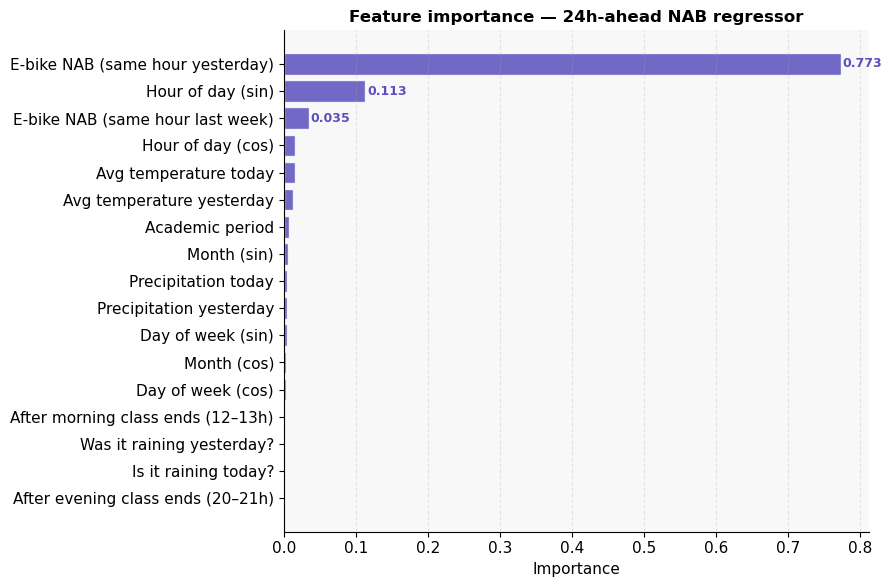

Saved: fig_feature_importance.png


In [15]:
# ── Feature importance ────────────────────────────────────────────────────
FEATURE_LABELS = {
    'NAB_lag24h'  : 'E-bike NAB (same hour yesterday)',
    'NAB_lag168h' : 'E-bike NAB (same hour last week)',
    'temp_prev'   : 'Avg temperature yesterday',
    'precip_prev' : 'Precipitation yesterday',
    'rain_prev'   : 'Was it raining yesterday?',
    'temp_today'  : 'Avg temperature today',
    'precip_today': 'Precipitation today',
    'rain_today'  : 'Is it raining today?',
    'dow_sin'     : 'Day of week (sin)',
    'dow_cos'     : 'Day of week (cos)',
    'month_sin'   : 'Month (sin)',
    'month_cos'   : 'Month (cos)',
    'hour_sin'    : 'Hour of day (sin)',
    'hour_cos'    : 'Hour of day (cos)',
    'is_academic' : 'Academic period',
    'after_morning_class': 'After morning class ends (12–13h)',
    'after_evening_class' : 'After evening class ends (20–21h)',
}

imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
labels = [FEATURE_LABELS.get(f, f) for f in imp.index]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(labels, imp.values, color=C_EBIKE, alpha=0.85, edgecolor='white')
# Annotate top 3
for i, (val, lbl) in enumerate(zip(imp.values[-3:], labels[-3:])):
    ax.text(val + 0.002, len(imp)-3+i,
            f'{val:.3f}', va='center', fontsize=9,
            color=C_EBIKE, fontweight='bold')
ax.set_title('Feature importance — 24h-ahead NAB regressor',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importance')
ax.grid(True, alpha=0.25, axis='x', linestyle='--')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_feature_importance.png')

Sample day: 2024-02-14 (Wednesday)


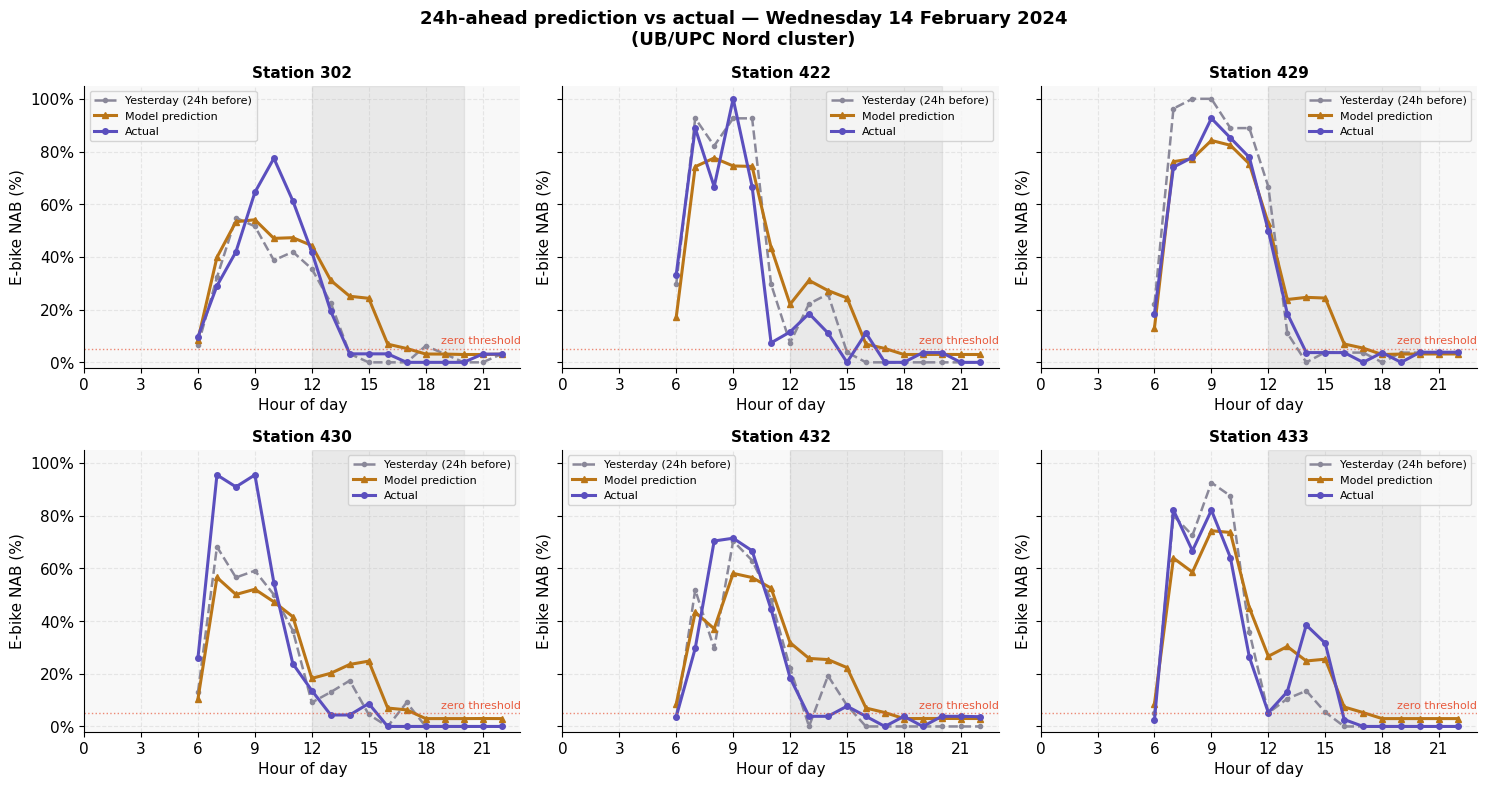

Saved: fig_prediction_3lines.png


In [16]:
# ── 3-line plot: yesterday / predicted / actual for a sample test day ─────
# Pick a weekday in the test set that has all stations present
test['pred'] = y_pred

# Find a good sample day: term-time weekday with high variance
test_days = (
    test.groupby('date_only')['station_id']
    .nunique()
    .reset_index()
)
full_days = test_days[test_days['station_id'] == test['station_id'].nunique()]
if len(full_days) == 0:
    full_days = test_days.nlargest(1, 'station_id')

# Pick a Tuesday in Oct-Nov (highest depletion month)
candidates = full_days[
    pd.to_datetime(full_days['date_only']).dt.month.isin([10,11]) &
    (pd.to_datetime(full_days['date_only']).dt.dayofweek == 1)
]
sample_date = pd.Timestamp(
    candidates['date_only'].iloc[0] if len(candidates) > 0
    else full_days['date_only'].iloc[len(full_days)//2]
)
prev_date = sample_date - pd.Timedelta(days=1)

print(f'Sample day: {sample_date.date()} ({sample_date.day_name()})')

sample_today = test[test['date_only'] == sample_date].sort_values(['station_id','hour'])
sample_prev  = nord_model[nord_model['date_only'] == prev_date].sort_values(['station_id','hour'])

sids = sorted(sample_today['station_id'].unique())
n_stations = len(sids)
ncols = min(3, n_stations)
nrows = (n_stations + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), sharey=True)
axes = np.array(axes).flatten()
fig.suptitle(f'24h-ahead prediction vs actual — {sample_date.strftime("%A %d %B %Y")}\n'
             f'(UB/UPC Nord cluster)',
             fontsize=13, fontweight='bold')

for ax, sid in zip(axes, sids):
    today_s = sample_today[sample_today['station_id'] == sid]
    prev_s  = sample_prev[sample_prev['station_id'] == sid]

    ax.plot(prev_s['hour'],  prev_s['ebike_NAB']*100,
            color=C_YEST, lw=1.8, linestyle='--',
            marker='o', ms=3, label='Yesterday (24h before)')
    ax.plot(today_s['hour'], today_s['pred']*100,
            color=C_PRED, lw=2.2,
            marker='^', ms=4, label='Model prediction')
    ax.plot(today_s['hour'], today_s['ebike_NAB']*100,
            color=C_ACTUAL, lw=2.2,
            marker='o', ms=4, label='Actual')

    ax.axhline(5, color=C_DEPL, lw=1, linestyle=':', alpha=0.7)
    ax.text(23, 7, 'zero threshold', ha='right', fontsize=8, color=C_DEPL)
    ax.axvspan(12, 20, alpha=0.06, color='black')
    ax.set_title(f'Station {int(sid)}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('E-bike NAB (%)')
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlim(0, 23)
    ax.set_ylim(-2, 105)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25, linestyle='--')

# Hide unused axes
for ax in axes[n_stations:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('fig_prediction_3lines.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_prediction_3lines.png')

In [17]:
# ── Baseline vs Random Forest MAE comparison ──────────────────────────────
# Baseline: simply use NAB from the same hour yesterday as the prediction
baseline_pred = test['NAB_lag24h'].values
rf_pred       = test['pred'].values
actual        = test[TARGET].values

mae_baseline = mean_absolute_error(actual, baseline_pred)
mae_rf       = mean_absolute_error(actual, rf_pred)
improvement  = (mae_baseline - mae_rf) / mae_baseline * 100

print('MAE COMPARISON — full test set (2024)')
print('=' * 45)
print(f'  Baseline (NAB same hour yesterday) : {mae_baseline:.4f}  ({mae_baseline*100:.2f}% NAB units)')
print(f'  Random Forest (all features)       : {mae_rf:.4f}  ({mae_rf*100:.2f}% NAB units)')
print(f'  Improvement                        : {improvement:.1f}%')

print('\nPer-station breakdown:')
print(f'  {"Station":<12} {"Baseline MAE":>14} {"RF MAE":>10} {"Improvement":>13}')
print('  ' + '-' * 52)
for sid in sorted(test['station_id'].unique()):
    mask   = test['station_id'] == sid
    mae_b  = mean_absolute_error(actual[mask], baseline_pred[mask])
    mae_r  = mean_absolute_error(actual[mask], rf_pred[mask])
    imp_s  = (mae_b - mae_r) / mae_b * 100
    print(f'  Station {int(sid):<6} {mae_b:>12.4f}   {mae_r:>8.4f}   {imp_s:>+10.1f}%')

MAE COMPARISON — full test set (2024)
  Baseline (NAB same hour yesterday) : 0.1466  (14.66% NAB units)
  Random Forest (all features)       : 0.1279  (12.79% NAB units)
  Improvement                        : 12.8%

Per-station breakdown:
  Station        Baseline MAE     RF MAE   Improvement
  ----------------------------------------------------
  Station 302          0.1528     0.1264        +17.2%
  Station 422          0.1347     0.1259         +6.5%
  Station 429          0.1811     0.1486        +17.9%
  Station 430          0.1473     0.1298        +11.9%
  Station 432          0.1332     0.1147        +13.8%
  Station 433          0.1304     0.1218         +6.6%


## 5 — Depletion classifier derived from predictions

**Definition:** a station-day is a depletion event if **predicted NAB < 5%** for **1 or more consecutive hours** between 12:00–20:00.  
No separate model — the classifier is a threshold applied to the regressor output.

In [18]:
def has_consecutive_below(series, threshold=0.05, n=1):
    count = 0
    for v in series:
        count = count + 1 if v < threshold else 0
        if count >= n:
            return 1
    return 0

# Apply to peak window
peak_test = test[test['hour'].between(12, 20)].copy()

# Actual depletion
actual_depletion = (
    peak_test
    .sort_values(['station_id','date_only','hour'])
    .groupby(['station_id','date_only'])['ebike_NAB']
    .apply(has_consecutive_below)
    .rename('actual_depleted')
    .reset_index()
)

# Predicted depletion (from model output)
pred_depletion = (
    peak_test
    .sort_values(['station_id','date_only','hour'])
    .groupby(['station_id','date_only'])['pred']
    .apply(has_consecutive_below)
    .rename('pred_depleted')
    .reset_index()
)

depletion_eval = actual_depletion.merge(pred_depletion, on=['station_id','date_only'])

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

y_true = depletion_eval['actual_depleted']
y_pred_cls = depletion_eval['pred_depleted']

print('DEPLETION CLASSIFIER (derived from regressor, threshold NAB < 5% for 1h+)')
print('='*65)
print(classification_report(y_true, y_pred_cls,
                             target_names=['No depletion','Depletion']))

print(f'Actual depletion rate : {y_true.mean():.1%}')
print(f'Predicted depletion rate: {y_pred_cls.mean():.1%}')

print('\nPer-station:')
for sid in sorted(depletion_eval['station_id'].unique()):
    mask = depletion_eval['station_id'] == sid
    yt = y_true[mask]
    yp = y_pred_cls[mask]
    from sklearn.metrics import precision_score, recall_score, f1_score
    print(f'  Station {int(sid):3d}  '
          f'actual={yt.mean():.0%}  '
          f'precision={precision_score(yt,yp,zero_division=0):.2f}  '
          f'recall={recall_score(yt,yp,zero_division=0):.2f}  '
          f'f1={f1_score(yt,yp,zero_division=0):.2f}')

DEPLETION CLASSIFIER (derived from regressor, threshold NAB < 5% for 1h+)
              precision    recall  f1-score   support

No depletion       0.50      0.75      0.60        61
   Depletion       0.95      0.86      0.90       329

    accuracy                           0.84       390
   macro avg       0.72      0.81      0.75       390
weighted avg       0.88      0.84      0.86       390

Actual depletion rate : 84.4%
Predicted depletion rate: 76.4%

Per-station:
  Station 302  actual=71%  precision=0.90  recall=0.93  f1=0.91
  Station 422  actual=95%  precision=0.96  recall=0.87  f1=0.92
  Station 429  actual=74%  precision=0.89  recall=0.69  f1=0.78
  Station 430  actual=88%  precision=1.00  recall=0.89  f1=0.94
  Station 432  actual=92%  precision=0.94  recall=0.85  f1=0.89
  Station 433  actual=86%  precision=0.98  recall=0.91  f1=0.94


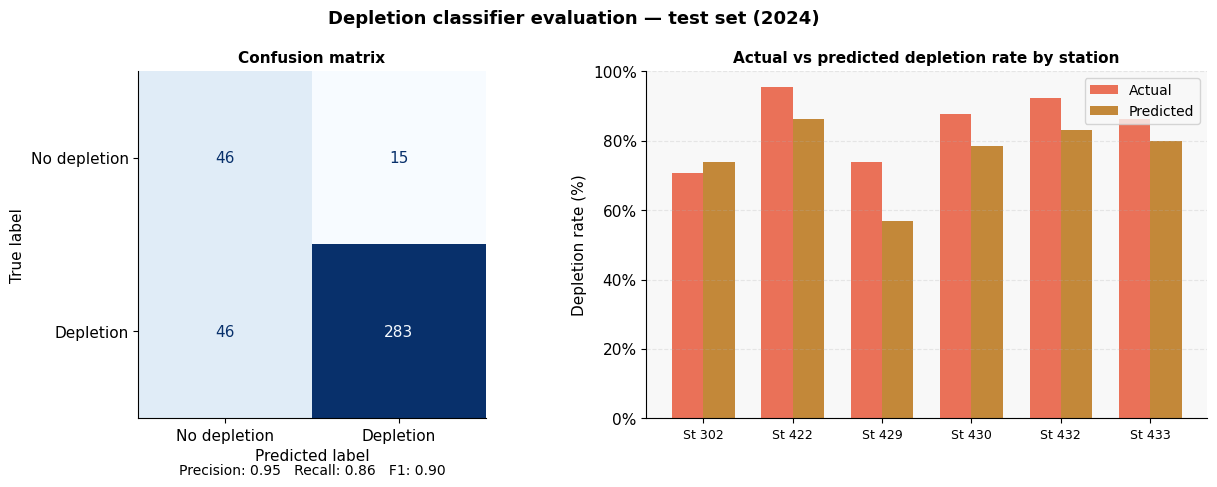

Saved: fig_depletion_classifier.png


In [19]:
# ── Confusion matrix + depletion timeline ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Depletion classifier evaluation — test set (2024)',
             fontsize=13, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_cls)
ConfusionMatrixDisplay(cm, display_labels=['No depletion','Depletion']).plot(
    ax=ax1, colorbar=False, cmap='Blues'
)
from sklearn.metrics import precision_score, recall_score, f1_score
p = precision_score(y_true, y_pred_cls, zero_division=0)
r = recall_score(y_true, y_pred_cls, zero_division=0)
f = f1_score(y_true, y_pred_cls, zero_division=0)
ax1.set_title('Confusion matrix', fontsize=11, fontweight='bold')
ax1.text(0.5, -0.16,
         f'Precision: {p:.2f}   Recall: {r:.2f}   F1: {f:.2f}',
         transform=ax1.transAxes, ha='center', fontsize=10)

# Depletion rate by station bar chart
station_dep = depletion_eval.groupby('station_id').agg(
    actual=('actual_depleted','mean'),
    predicted=('pred_depleted','mean')
).reset_index()

x = np.arange(len(station_dep))
w = 0.35
ax2.bar(x - w/2, station_dep['actual']*100,    w, label='Actual',    color=C_DEPL, alpha=0.85)
ax2.bar(x + w/2, station_dep['predicted']*100, w, label='Predicted', color=C_PRED, alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels([f'St {int(s)}' for s in station_dep['station_id']], fontsize=9)
ax2.set_ylabel('Depletion rate (%)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax2.set_title('Actual vs predicted depletion rate by station', fontsize=11, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.25, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('fig_depletion_classifier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_depletion_classifier.png')

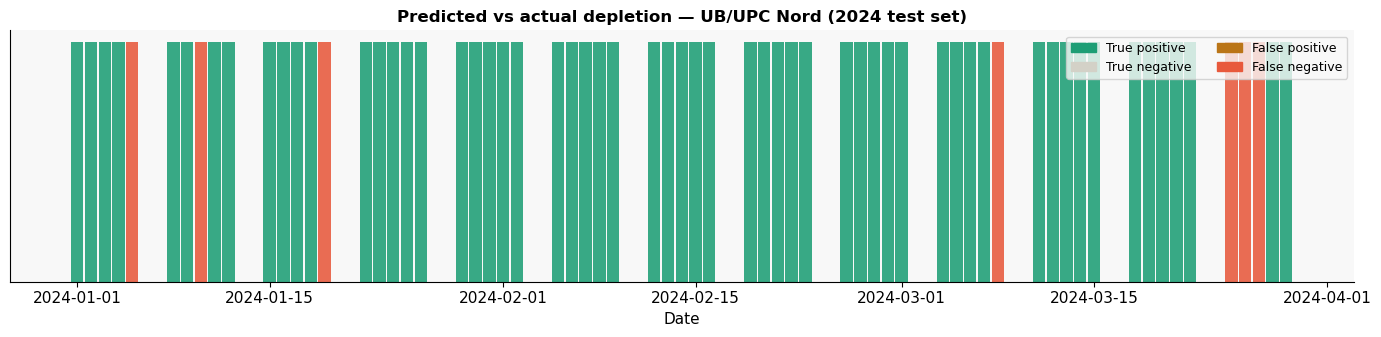

Saved: fig_depletion_timeline.png

Day-level accuracy: 58/65 (89.2%)
outcome
True positive     58
False negative     7


In [20]:
# ── Prediction timeline — predicted vs actual depletion over 2024 ─────────
# Aggregate to one row per day (any station depleted = day depleted)
daily_eval = (
    depletion_eval
    .groupby('date_only')
    .agg(actual=('actual_depleted','max'),
         predicted=('pred_depleted','max'))
    .reset_index()
    .sort_values('date_only')
)
daily_eval['date_only'] = pd.to_datetime(daily_eval['date_only'])

def outcome(row):
    if row['actual'] == 1 and row['predicted'] == 1: return 'True positive'
    if row['actual'] == 0 and row['predicted'] == 0: return 'True negative'
    if row['actual'] == 0 and row['predicted'] == 1: return 'False positive'
    return 'False negative'

daily_eval['outcome'] = daily_eval.apply(outcome, axis=1)

OUTCOME_COLORS = {
    'True positive'  : C_MECH,
    'True negative'  : '#D3D1C7',
    'False positive' : C_PRED,
    'False negative' : C_DEPL,
}

fig, ax = plt.subplots(figsize=(14, 3.5))
for _, row in daily_eval.iterrows():
    ax.bar(row['date_only'], 1,
           color=OUTCOME_COLORS[row['outcome']],
           width=0.9, alpha=0.88)

handles = [mpatches.Patch(color=c, label=l)
           for l, c in OUTCOME_COLORS.items()]
ax.legend(handles=handles, fontsize=9, loc='upper right', ncol=2)
ax.set_yticks([])
ax.set_title('Predicted vs actual depletion — UB/UPC Nord (2024 test set)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.grid(False)
plt.tight_layout()
plt.savefig('fig_depletion_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_depletion_timeline.png')

correct = daily_eval['outcome'].isin(['True positive','True negative']).sum()
total   = len(daily_eval)
print(f'\nDay-level accuracy: {correct}/{total} ({correct/total:.1%})')
print(daily_eval['outcome'].value_counts().to_string())

Note: This is an average of all stations. A more honest view would be one where we show it per station.

Outcome counts at station-day level:
outcome
True positive     283
True negative      46
False negative     46
False positive     15


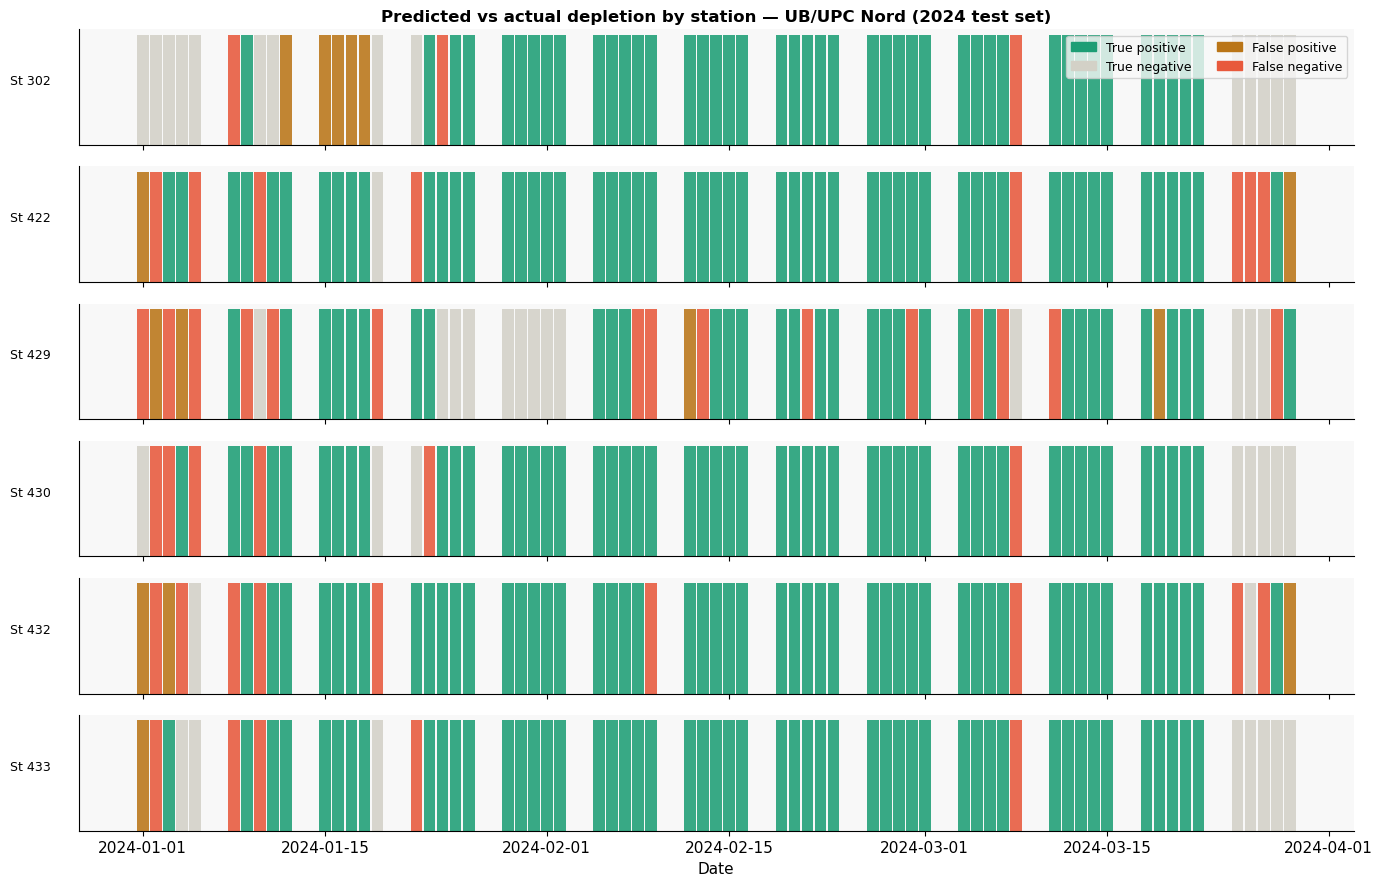


Station-day accuracy: 329/390 (84.4%)


In [21]:
# ── Prediction timeline — station-day level (shows false positives) ───────
def outcome_station(row):
    if row['actual_depleted'] == 1 and row['pred_depleted'] == 1: return 'True positive'
    if row['actual_depleted'] == 0 and row['pred_depleted'] == 0: return 'True negative'
    if row['actual_depleted'] == 0 and row['pred_depleted'] == 1: return 'False positive'
    return 'False negative'

station_eval = depletion_eval.copy()
station_eval['date_only'] = pd.to_datetime(station_eval['date_only'])
station_eval['outcome'] = station_eval.apply(outcome_station, axis=1)

print('Outcome counts at station-day level:')
print(station_eval['outcome'].value_counts().to_string())

# Plot one row per station, stacked vertically
sids = sorted(station_eval['station_id'].unique())
fig, axes = plt.subplots(len(sids), 1,
                         figsize=(14, 1.5 * len(sids)),
                         sharex=True)

for ax, sid in zip(axes, sids):
    s = station_eval[station_eval['station_id'] == sid].sort_values('date_only')
    for _, row in s.iterrows():
        ax.bar(row['date_only'], 1,
               color=OUTCOME_COLORS[row['outcome']],
               width=0.9, alpha=0.88)
    ax.set_yticks([])
    ax.set_ylabel(f'St {int(sid)}', fontsize=9, rotation=0, labelpad=35)
    ax.grid(False)

handles = [mpatches.Patch(color=c, label=l)
           for l, c in OUTCOME_COLORS.items()]
axes[0].legend(handles=handles, fontsize=9, loc='upper right', ncol=2)
axes[0].set_title(
    'Predicted vs actual depletion by station — UB/UPC Nord (2024 test set)',
    fontsize=12, fontweight='bold'
)
axes[-1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('fig_depletion_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

correct = (station_eval['outcome'].isin(['True positive','True negative'])).sum()
total   = len(station_eval)
print(f'\nStation-day accuracy: {correct}/{total} ({correct/total:.1%})')

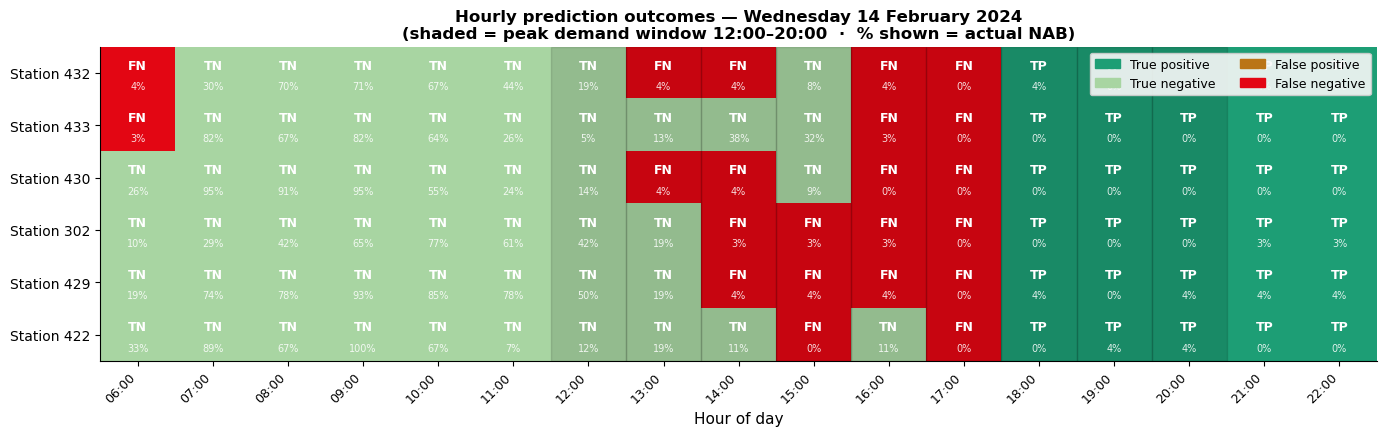

Saved: fig_depletion_heatmap.png


In [24]:
# ── Hourly outcome heatmap — single day, all 6 stations ───────────────────
# Shows TP / TN / FP / FN per station per hour for a chosen test day
# within the peak window 06:00–22:00

OUTCOME_COLORS_HM = {
    'True positive'  : '#1D9E75',   # green  — correctly flagged depletion
    'True negative'  : '#A8D5A2',   # light green — correctly flagged no depletion  
    'False positive' : '#BA7517',   # amber  — predicted depletion, was fine
    'False negative' : '#E30613',   # red    — missed a real depletion
    'No data'        : '#E8E8E8',   # gray   — hour not in test set
}
OUTCOME_LABELS = {
    'True positive'  : 'TP',
    'True negative'  : 'TN',
    'False positive' : 'FP',
    'False negative' : 'FN',
    'No data'        : '',
}

THRESHOLD = 0.05  # 5% NAB = depleted

# Get all hours for sample_date
day_data = test[test['date_only'] == sample_date].copy()
day_data['actual_dep']  = (day_data['ebike_NAB'] < THRESHOLD).astype(int)
day_data['pred_dep']    = (day_data['pred']       < THRESHOLD).astype(int)

def hourly_outcome(actual, predicted):
    if actual == 1 and predicted == 1: return 'True positive'
    if actual == 0 and predicted == 0: return 'True negative'
    if actual == 0 and predicted == 1: return 'False positive'
    return 'False negative'

day_data['outcome'] = day_data.apply(
    lambda r: hourly_outcome(r['actual_dep'], r['pred_dep']), axis=1
)

# Pivot to stations × hours
HOURS = list(range(6, 23))
pivot_outcome = day_data.pivot(
    index='station_id', columns='hour', values='outcome'
).reindex(columns=HOURS)
pivot_outcome.index = [f'Station {int(s)}' for s in pivot_outcome.index]
pivot_outcome = pivot_outcome.fillna('No data')

# Sort by earliest false negative (most interesting story first)
def first_fn(row):
    for h in HOURS:
        if row[h] == 'False negative': return h
    for h in HOURS:
        if row[h] == 'True positive': return h + 24
    return 99

pivot_outcome['_sort'] = pivot_outcome.apply(first_fn, axis=1)
pivot_outcome = pivot_outcome.sort_values('_sort').drop(columns='_sort')

# Convert outcomes to numeric for imshow
outcome_order = ['True positive','True negative','False positive','False negative','No data']
outcome_to_num = {o: i for i, o in enumerate(outcome_order)}
numeric = pivot_outcome.applymap(lambda x: outcome_to_num.get(x, 4))

cmap_hm = mcolors.ListedColormap([OUTCOME_COLORS_HM[o] for o in outcome_order])

fig, ax = plt.subplots(figsize=(14, 4.5))

im = ax.imshow(
    numeric.values,
    aspect='auto',
    cmap=cmap_hm,
    vmin=0, vmax=len(outcome_order) - 1,
    interpolation='nearest'
)

# Annotate each cell with TP/TN/FP/FN and the actual NAB value
for row_idx, station in enumerate(pivot_outcome.index):
    for col_idx, hour in enumerate(HOURS):
        outcome = pivot_outcome.loc[station, hour]
        label   = OUTCOME_LABELS.get(outcome, '')

        # Get actual NAB for context
        match = day_data[
            (day_data['station_id'] == int(station.replace('Station ',''))) &
            (day_data['hour'] == hour)
        ]
        if len(match) > 0:
            nab_val = match['ebike_NAB'].values[0] * 100
            ax.text(col_idx, row_idx - 0.15, label,
                    ha='center', va='center', fontsize=9,
                    fontweight='bold', color='white')
            ax.text(col_idx, row_idx + 0.25, f'{nab_val:.0f}%',
                    ha='center', va='center', fontsize=7,
                    color='white', alpha=0.85)

# Shade peak window
for col_idx, hour in enumerate(HOURS):
    if 12 <= hour <= 20:
        ax.axvspan(col_idx - 0.5, col_idx + 0.5,
                   alpha=0.12, color='black', zorder=0)

# Axes
ax.set_xticks(range(len(HOURS)))
ax.set_xticklabels([f'{h:02d}:00' for h in HOURS],
                   rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot_outcome.index)))
ax.set_yticklabels(pivot_outcome.index, fontsize=10)
ax.set_xlabel('Hour of day', fontsize=11)
ax.set_title(
    f'Hourly prediction outcomes — {sample_date.strftime("%A %d %B %Y")}\n'
    f'(shaded = peak demand window 12:00–20:00  ·  % shown = actual NAB)',
    fontsize=12, fontweight='bold'
)

# Legend
handles = [mpatches.Patch(color=OUTCOME_COLORS_HM[o], label=o)
           for o in outcome_order if o != 'No data']
ax.legend(handles=handles, fontsize=9, loc='upper right',
          ncol=2, framealpha=0.9)

plt.tight_layout()
plt.savefig('fig_depletion_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_depletion_heatmap.png')

In [23]:
# ── Revenue opportunity during depletion events (2024 test set) ───────────
# Logic: during hours where actual ebikes == 0 (or near-zero),
# we estimate how many rides were missed by looking at the average
# departures at that same hour on non-depleted days (demand proxy).
# Each missed ride = €0.10 in lost e-bike fee revenue.

FEE_PER_RIDE = 0.10

# Hourly departures proxy: negative delta in ebike count = net departures
# (bikes going out minus bikes coming back in that hour)
test_sorted = test.sort_values(['station_id', 'date', 'hour'])
test_sorted['ebike_delta'] = test_sorted.groupby('station_id')['ebikes'].diff()
test_sorted['departures']  = test_sorted['ebike_delta'].clip(upper=0).abs()

# Define depleted hours: NAB < 5% (effectively zero)
test_sorted['is_depleted'] = (test_sorted['ebike_NAB'] < 0.05).astype(int)

# Average departures per station per hour when NOT depleted (demand proxy)
normal_demand = (
    test_sorted[test_sorted['is_depleted'] == 0]
    .groupby(['station_id', 'hour'])['departures']
    .mean()
    .rename('avg_demand_when_stocked')
    .reset_index()
)

# Join demand proxy onto depleted hours only
depleted_hours = test_sorted[test_sorted['is_depleted'] == 1].copy()
depleted_hours = depleted_hours.merge(
    normal_demand, on=['station_id', 'hour'], how='left'
)
depleted_hours['avg_demand_when_stocked'] = (
    depleted_hours['avg_demand_when_stocked'].fillna(0)
)
depleted_hours['lost_rides']   = depleted_hours['avg_demand_when_stocked']
depleted_hours['lost_revenue'] = depleted_hours['lost_rides'] * FEE_PER_RIDE

# ── Summary ────────────────────────────────────────────────────────────────
total_depleted_hours = len(depleted_hours)
total_lost_rides     = depleted_hours['lost_rides'].sum()
total_lost_revenue   = depleted_hours['lost_revenue'].sum()

# Break down by month
depleted_hours['month'] = pd.to_datetime(depleted_hours['date_only']).dt.month
MONTH_NAMES = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May'}

print('REVENUE OPPORTUNITY — UB/UPC Nord test set (Jan–May 2024)')
print('=' * 60)
print(f'\nAssumption: if restocked at zero-hours, all avg_demand rides occur')
print(f'Fee per e-bike ride: €{FEE_PER_RIDE:.2f}')
print()
print(f'  Total depleted station-hours : {total_depleted_hours:,}')
print(f'  Estimated missed rides       : {total_lost_rides:,.0f}')
print(f'  Estimated lost revenue       : €{total_lost_revenue:,.2f}')

print(f'\n  Monthly breakdown:')
print(f'  {"Month":<8} {"Depleted hrs":>14} {"Missed rides":>14} {"Lost revenue":>14}')
print('  ' + '-' * 55)
for month, grp in depleted_hours.groupby('month'):
    name    = MONTH_NAMES.get(month, str(month))
    hrs     = len(grp)
    rides   = grp['lost_rides'].sum()
    revenue = grp['lost_revenue'].sum()
    print(f'  {name:<8} {hrs:>14,} {rides:>14,.0f} {revenue:>13,.2f}€')

print(f'\n  Per-station breakdown:')
print(f'  {"Station":<12} {"Depleted hrs":>14} {"Missed rides":>14} {"Lost revenue":>14}')
print('  ' + '-' * 57)
for sid, grp in depleted_hours.groupby('station_id'):
    hrs     = len(grp)
    rides   = grp['lost_rides'].sum()
    revenue = grp['lost_revenue'].sum()
    print(f'  Station {int(sid):<6} {hrs:>14,} {rides:>14,.0f} {revenue:>13,.2f}€')

print(f'\n  Annualised estimate (×12/5 months, term-time only):')
annual = total_lost_revenue * 12 / 5
print(f'  Projected annual lost revenue (6 stations) : €{annual:,.2f}')
print(f'\nNote: conservative lower bound — assumes demand = avg departures')
print('when stocked. Does not account for suppressed demand or')
print('riders who gave up before arriving at the station.')

REVENUE OPPORTUNITY — UB/UPC Nord test set (Jan–May 2024)

Assumption: if restocked at zero-hours, all avg_demand rides occur
Fee per e-bike ride: €0.10

  Total depleted station-hours : 1,998
  Estimated missed rides       : 3,139
  Estimated lost revenue       : €313.90

  Monthly breakdown:
  Month      Depleted hrs   Missed rides   Lost revenue
  -------------------------------------------------------
  Jan                 579            783         78.35€
  Feb                 777          1,284        128.43€
  Mar                 642          1,071        107.13€

  Per-station breakdown:
  Station        Depleted hrs   Missed rides   Lost revenue
  ---------------------------------------------------------
  Station 302               286            434         43.43€
  Station 422               402            753         75.28€
  Station 429               245            199         19.95€
  Station 430               340            382         38.16€
  Station 432               3